<h1><center>Informe Técnico: Predicción de lluvia en Australia</center></h1>

### Integrantes:


*   Lino Barrera
*   Pablo Castro
*   Jordán Órdenes

### Profesor:
Yerko Paredes

### Asignatura:
Minería de Datos

Este informe técnico se enmarca bajo la metodología CRISP-DM, la cual consta de 6 fases integrales: 
1. Comprensión del Negocio, 
2. Comprensión de los Datos, 
3. Preparación de los Datos, 
4. Modelado, 
5. Evaluación, e
6. Implementación.

La aplicación sistemática de estas fases es de altísimo valor, ya que permite transformar datos crudos en conocimiento accionable, reduciendo la incertidumbre y apoyando directamente la toma de decisiones estratégicas de la compañía.

## Fase 1: Comprensión del Negocio

El problema consiste en analizar datos meteorológicos históricos de Australia para predecir si lloverá al día siguiente (RainTomorrow). En este proyecto, nos posicionaremos como consultores de datos para Top Wheat, una gran empresa agroindustrial dedicada a la plantación y cosecha de trigo, con un tamaño de explotación de 3000 hectáreas, ubicada en la región del Wheatbelt en Western Australia.

El trigo es un cultivo altamente dependiente de las condiciones climáticas. Conocer con precisión si habrá precipitaciones en las próximas 24 horas es vital para el éxito de la temporada, ya que un error en la planificación meteorológica puede arruinar meses de trabajo o generar enormes pérdidas por desperdicio de insumos.

1. Objetivos Claves del Negocio:
Para Top Wheat, el modelo predictivo debe apuntar a resolver dos problemas operativos distintos:
    * Objetivo 1: Optimización del uso de agroquímicos (Ahorro de Costos). Los fertilizantes y pesticidas son insumos muy costosos. Si se aplican en el campo y al día siguiente llueve, el agua "lava" los productos químicos (escorrentía), perdiendo el dinero invertido y dañando el medio ambiente. El objetivo es evitar aplicaciones en las 24 horas previas a una lluvia.
    * Objetivo 2: Protección de la cosecha y calidad del grano (Maximización de Ingresos). Si llueve sobre el trigo maduro justo antes o durante los días de cosecha, el grano puede brotar prematuramente o desarrollar hongos, perdiendo su calidad comercial. El objetivo es anticipar las lluvias para acelerar la recolección o proteger el grano ya cortado.

2. KPIs Relevantes (Indicadores de Éxito):
El éxito de este proyecto de Minería de Datos se medirá conectando las métricas del modelo con el impacto en el negocio del trigo:
    * Reducción de la pérdida de cosechas al menos a un 10%. En el período anterior, la pérdida de cosechas fue de un 20%, por lo que con este nuevo enfoque de minería de datos, la empresa estableció que la meta es bajar la pérdida al menos a un 10%.
    * Reducción del costo de los pesticidas en un 20%. Al predecir correctamente los períodos de lluvia, se espera reducir el dinero invertido al haber menor cantidad de pesticidas lavados por la lluvia.

Actualmente, Top Wheat no posee un sistema de predicción de lluvias, lo que aumenta la pérdida de cosechas y el costo de los pesticidas. El año 2025, Top Wheat registró un 20% de pérdida de cosechas por lluvias, y un costo mensual del uso de pesticidas de $40,000 dólares australianos, por lo que requiere un enfoque de minería de datos para ayudar a solucionar este problema.

## Fase 2: Comprensión de los Datos
2.1 Características y Naturaleza de los Datos

* Naturaleza Temporal: La variable Date indica que estamos ante una Serie de Tiempo. El clima tiene estacionalidad, lo cual es clave para el análisis.

* Variables Numéricas Continuas: Temperaturas (MinTemp, MaxTemp), Humedad (Humidity9am), Presión (Pressure9am), Velocidad del viento, etc.

* Variables Categóricas: Ubicación (Location), Direcciones del viento (WindGustDir), y las variables binarias (RainToday, RainTomorrow).

* Objetivo del Análisis: Entender la distribución de estas variables, cómo interactúan entre sí, y cómo separan las clases de la variable objetivo (RainTomorrow).

In [69]:
import pandas as pd

# Configuración para visualizar todas las columnas
pd.set_option('display.max_columns', None)

# Configuración para visualizar todas las filas
pd.set_option('display.max_rows', None)

# Cargar los datos desde un archivo csv
file_path = "weatherAUS.csv"
df = pd.read_csv(file_path, header=0)

df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


Tamaño del dataset

In [70]:
df.shape

(142193, 24)

Tipos de datos de las columnas

In [71]:
df.dtypes

Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RISK_MM          float64
RainTomorrow         str
dtype: object

Estadísticos

In [72]:
# Numéricas
df.describe() 

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


In [73]:
# Categóricas
df.describe(include=['object']) 

/tmp/ipykernel_37785/3160744110.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,142193,142193,132863,132180,138415,140787,142193
unique,3436,49,16,16,16,2,2
top,2013-03-02,Canberra,W,N,SE,No,No
freq,49,3418,9780,11393,10663,109332,110316


2.2 Estadísticos e Insights Relevantes

Al observar los estadísticos de los datos completos, podemos identificar los siguientes insights relevantes:

* Distribución de la Lluvia (Rainfall): La mayoría de los días (hasta el percentil 75) registran 0 o muy pocos milímetros de lluvia. Sin embargo, el valor máximo es altísimo. Esto nos indica una distribución muy asimétrica (sesgada a la derecha).

* Rango de Temperaturas: Existe una clara diferencia entre las mediciones de las 9am y las 3pm, siendo las de la tarde consistentemente más altas y con menor humedad, mostrando el ciclo térmico diario normal.

* Presión Atmosférica: Suele tener desviaciones estándar bajas. Sin embargo, las caídas bruscas en la presión atmosférica históricamente están ligadas a la presencia de lluvia.

Las variables categóricas muestran que la dirección del viento predominante varía, y que los días sin lluvia (No) son considerablemente más frecuentes que los días con lluvia (Yes), lo que indica un desbalance de clases.

Recuento de valores nulos de cada columna

In [74]:
nulos_ordenados = df.isna().sum().sort_values(ascending=True)

for feature, cantidad in nulos_ordenados.items():
    print('Total de valores nulos de', feature, '=', cantidad)

Total de valores nulos de Date = 0
Total de valores nulos de Location = 0
Total de valores nulos de RainTomorrow = 0
Total de valores nulos de RISK_MM = 0
Total de valores nulos de MaxTemp = 322
Total de valores nulos de MinTemp = 637
Total de valores nulos de Temp9am = 904
Total de valores nulos de WindSpeed9am = 1348
Total de valores nulos de RainToday = 1406
Total de valores nulos de Rainfall = 1406
Total de valores nulos de Humidity9am = 1774
Total de valores nulos de WindSpeed3pm = 2630
Total de valores nulos de Temp3pm = 2726
Total de valores nulos de Humidity3pm = 3610
Total de valores nulos de WindDir3pm = 3778
Total de valores nulos de WindGustSpeed = 9270
Total de valores nulos de WindGustDir = 9330
Total de valores nulos de WindDir9am = 10013
Total de valores nulos de Pressure3pm = 13981
Total de valores nulos de Pressure9am = 14014
Total de valores nulos de Cloud9am = 53657
Total de valores nulos de Cloud3pm = 57094
Total de valores nulos de Evaporation = 60843
Total de val

Visualización de valores atípicos (Outliers) usando Boxplots

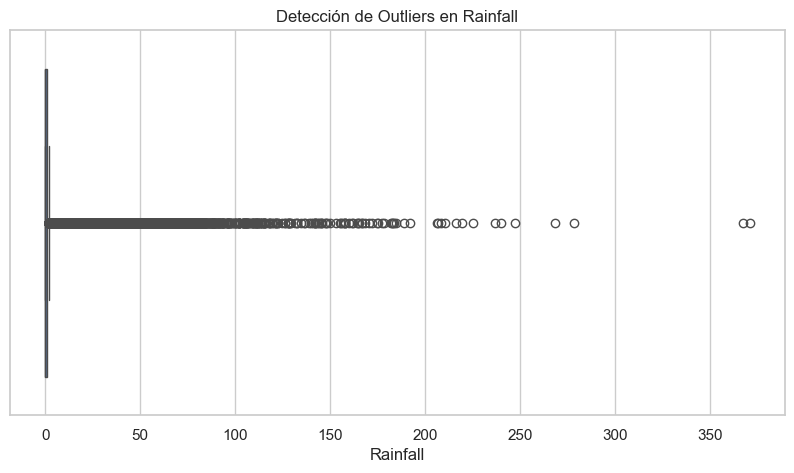

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Rainfall'])
plt.title('Detección de Outliers en Rainfall')
plt.show()

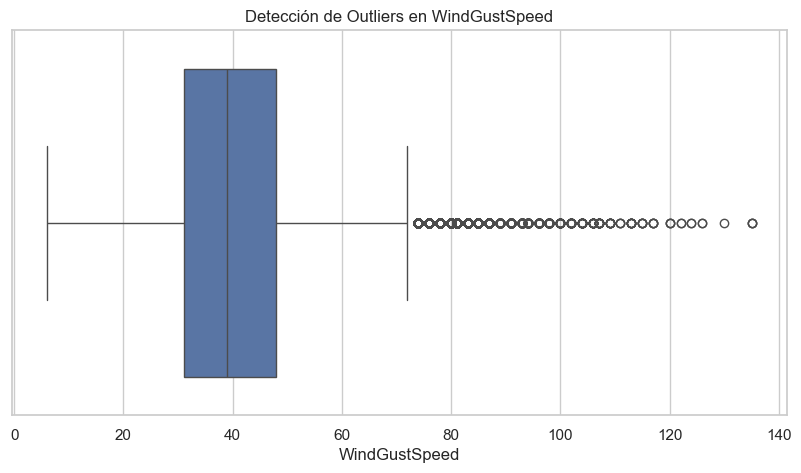

In [76]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['WindGustSpeed'])
plt.title('Detección de Outliers en WindGustSpeed')
plt.show()

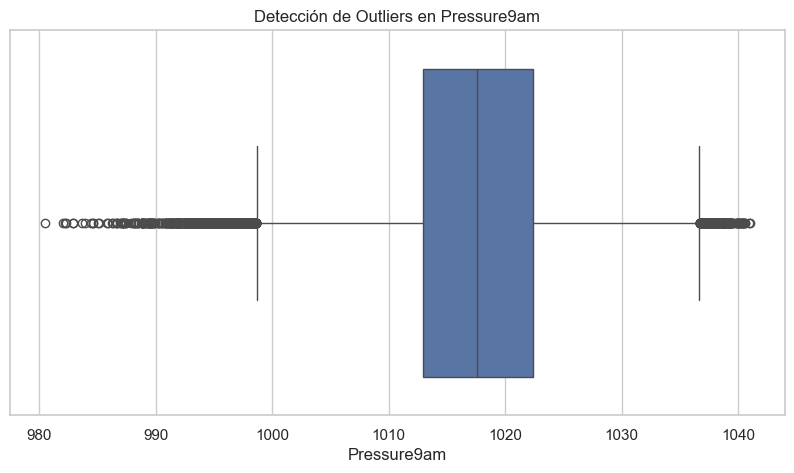

In [77]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Pressure9am'])
plt.title('Detección de Outliers en Pressure9am')
plt.show()

2.3 Valores Atípicos, Perdidos y Rutinas de Limpieza

Valores Perdidos (Missing Values):
Se observan múltiples variables con datos nulos (ej. Evaporation, Sunshine, Cloud9am, etc.).
    
Propuesta de limpieza: 
* Para columnas con más del 20% de datos nulos (como Sunshine o Evaporation), se propone eliminar la columna para evitar introducir ruido. 
* Para variables meteorológicas continuas con pocos nulos, se propone imputar usando la mediana (ya que la media es sensible a outliers). 
* Para categóricas (como WindGustDir), se imputará con la moda (valor más frecuente) según la ubicación (Location).

Valores Atípicos (Outliers):
* El gráfico de caja muestra claros outliers en variables como Rainfall o WindGustSpeed.
* Propuesta de limpieza: No debemos eliminar estos outliers indiscriminadamente, ya que representan eventos climáticos extremos reales (tormentas) que son fundamentales para predecir si lloverá. 
La rutina será aplicar Transformaciones Logarítmicas a variables como Rainfall para reducir la asimetría y el sesgo del modelo, sin perder la información valiosa de las tormentas.

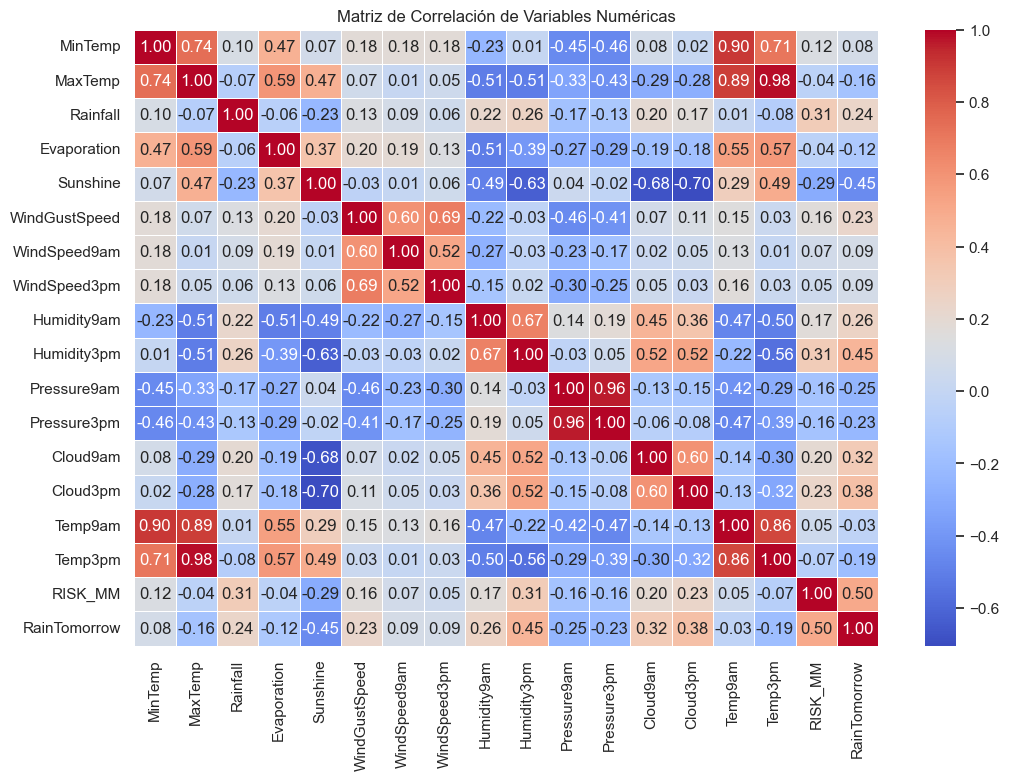

In [78]:
# Matriz de correlación
# Excluimos variables categóricas para evitar errores en el cálculo
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1}) # Convertir variable target a binario

num_df = df.select_dtypes(include=['float64', 'int64'])

# Calculamos la matriz de correlación
matriz_corr = num_df.corr()

# Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

A partir del mapa de calor generado (utilizando la correlación de Pearson para capturar relaciones lineales), identificamos los siguientes insights clave para el modelo:

* Correlaciones Positivas Fuertes (Multicolinealidad):

    Se observa una altísima correlación entre mediciones de la misma variable térmica/atmosférica en distintos horarios: Pressure9am y Pressure3pm (0.96), Temp3pm y MaxTemp (0.98), y Temp9am y MinTemp (0.90).

    Interpretación y Valor: Esto nos alerta de una fuerte multicolinealidad en el dataset. Entregarle ambas variables al algoritmo aportará información redundante y aumentará la complejidad del modelo sin agregar valor. Esto justifica plenamente la decisión de crear variables combinadas (como las variables Delta de diferencia diaria) y eliminar las columnas originales para el posterior entrenamiento.

* Correlaciones Negativas Relevantes:

    La variable Sunshine (horas de sol) presenta una fuerte correlación negativa con la nubosidad (Cloud3pm con -0.70) y la humedad (Humidity3pm con -0.63). A su vez, se correlaciona de forma negativa directa con nuestra variable objetivo RainTomorrow (-0.45).

    Interpretación y Valor: Los datos confirman numéricamente el comportamiento del clima local: la falta de radiación solar directa está fuertemente asociada a la retención de humedad en la tarde (Humidity3pm), la cual resulta ser el mejor predictor legítimo (0.45) para anticipar tormentas que podrían afectar a los cultivos de Top Wheat.

⚠️ ALERTA DE FUGA DE DATOS (Data Leakage) - RISK_MM:

    La variable RISK_MM presenta la mayor correlación positiva (0.50) con RainTomorrow. Desde el conocimiento del negocio, RISK_MM representa los milímetros exactos de lluvia registrados al día siguiente.

    Interpretación y Valor: Utilizar esta variable en la Fase de Modelado equivaldría a "predecir el futuro haciendo trampa", ya que en un escenario real la compañía agrícola no dispondrá de este dato con 24 horas de anticipación. Esta variable debe ser eliminada obligatoriamente en la fase de Preparación de Datos para que el modelo sea válido en la vida real.

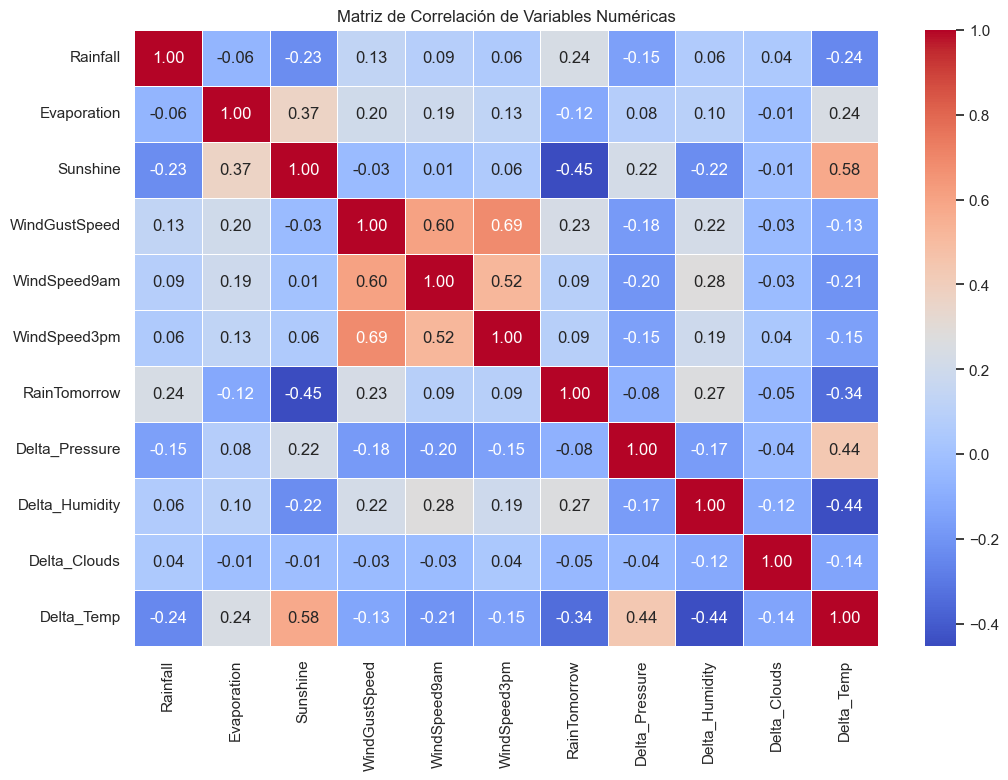

In [79]:
# Creación de variables de diferencia
num_df['Delta_Pressure'] = num_df['Pressure9am'] - num_df['Pressure3pm']
num_df['Delta_Humidity'] = num_df['Humidity3pm'] - num_df['Humidity9am']
num_df['Delta_Clouds'] = num_df['Cloud9am'] - num_df['Cloud3pm']
num_df['Delta_Temp'] = num_df['MaxTemp'] - num_df['MinTemp']

#Eliminamos columnas no relevantes
num_df = num_df.drop(columns=['Pressure9am', 'Pressure3pm', 'Humidity3pm', 'Humidity9am', 'Cloud9am', 'Cloud3pm', 'MaxTemp', 'MinTemp', 'Temp9am', 'Temp3pm', 'RISK_MM'])

# Calculamos la matriz de correlación
matriz_corr = num_df.corr()

# Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

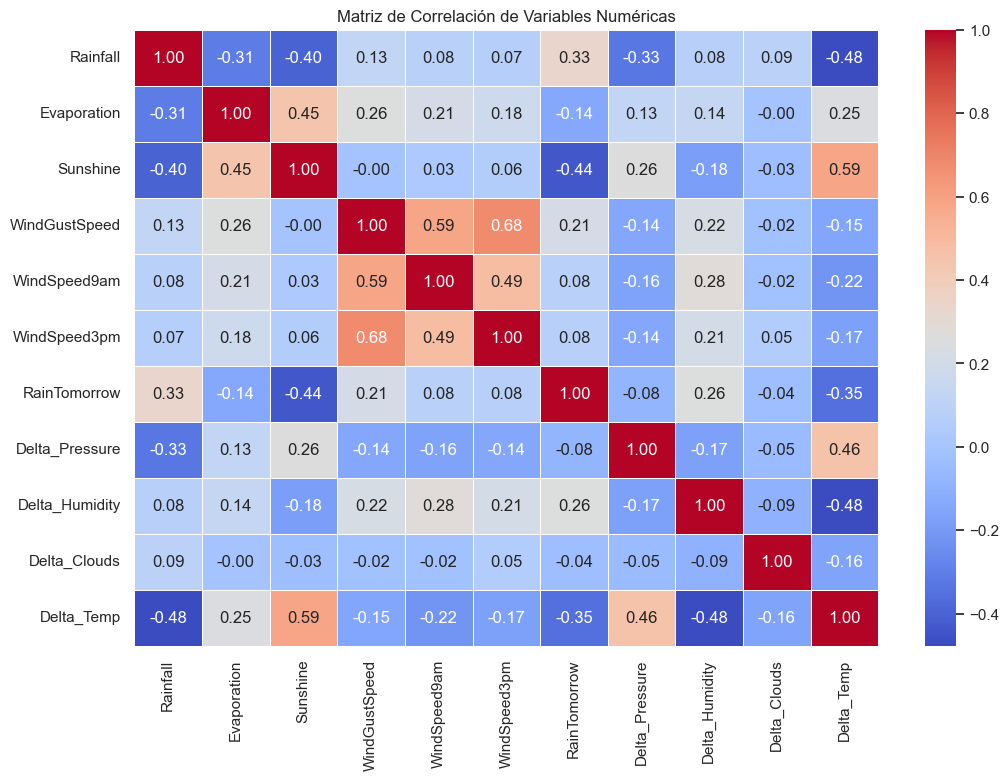

In [80]:
# Calculamos la matriz de correlación
spearman_corr = num_df.corr(method='spearman')

# Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

2.5 Modelo: Árbol de Decisión
En esta sección, transformamos los datos crudos en indicadores de cambio atmosférico. El enfoque principal es capturar la tendencia del clima (por ejemplo, si la presión está bajando) en lugar de solo observar el valor estático.

Nota: Aunque este encargo se centra en las fases 1 y 2 de CRISP-DM, se ha desarrollado un Árbol de Decisión preliminar (Baseline) con el fin de validar empíricamente la necesidad de las rutinas de limpieza propuestas y guiar la planificación de las Fases posteriores (Data Preparation y Modeling).

2.5.1 Preprocesamiento e Imputación de Nulos
Antes de entrenar el modelo, debemos asegurar que no existan valores vacíos. Utilizaremos una estrategia de imputación simple pero efectiva para datos tabulares:

In [81]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree_df = df.copy() # Copia del dataframe original para trabajar con el árbol de decisión

# Creación de variables de diferencia
tree_df['Delta_Pressure'] = tree_df['Pressure9am'] - tree_df['Pressure3pm']
tree_df['Delta_Humidity'] = tree_df['Humidity3pm'] - tree_df['Humidity9am']
tree_df['Delta_Clouds'] = tree_df['Cloud9am'] - tree_df['Cloud3pm']
tree_df['Delta_Temp'] = tree_df['MaxTemp'] - tree_df['MinTemp']


# 1. Separar columnas por tipo
numeric_cols = tree_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = tree_df.select_dtypes(include=['object']).columns.tolist()

# 2. Imputación de valores nulos
# Mediana para numéricas (resistente a outliers)
imputer_num = SimpleImputer(strategy='median')
tree_df[numeric_cols] = imputer_num.fit_transform(tree_df[numeric_cols])

# Moda para categóricas
imputer_cat = SimpleImputer(strategy='most_frequent')
tree_df[categorical_cols] = imputer_cat.fit_transform(tree_df[categorical_cols])

/tmp/ipykernel_37785/3263905651.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = tree_df.select_dtypes(include=['object']).columns.tolist()


In [82]:
tree_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Delta_Pressure,Delta_Humidity,Delta_Clouds,Delta_Temp
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,0.0,0.0,0.6,-49.0,0.0,9.5
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,0.0,0.0,2.8,-19.0,0.0,17.7
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,0.0,0.0,-1.1,-8.0,0.0,12.8
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,1.0,0.0,4.8,-29.0,0.0,18.8
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,0.0,4.8,-49.0,-1.0,14.8


Ingeniería de Características (Deltas)

Sustituimos las mediciones de mañana/tarde por variables de diferencia, que son predictores mucho más potentes para un árbol de decisión:
* Delta Presión (Delta_Pressure): Pressure9am - Pressure3pm. Un valor positivo indica que la presión bajó durante el día (típico antes de una tormenta).
* Delta Humedad (Delta_Humidity): Humidity3pm - Humidity9am. Mide cuánto se saturó el aire.
* Delta Temperatura (Delta_Temp): MaxTemp - MinTemp. Representa la amplitud térmica.

In [83]:
# Definición de variables predictoras finales
features = ['Delta_Pressure', 'Delta_Humidity', 'Delta_Temp', 
            'Rainfall', 'WindGustSpeed', 'Sunshine', 'Delta_Clouds']

X = tree_df[features]
y = tree_df['RainTomorrow']

# División del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Configuramos el árbol con una profundidad máxima para mantener la interpretabilidad y evitar que el modelo "memorice" los datos (overfitting).

In [84]:
# Inicializar y entrenar
clf = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Predicción y Evaluación
y_pred = clf.predict(X_test)

print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         0.0       0.82      0.97      0.89     22098
         1.0       0.69      0.27      0.39      6341

    accuracy                           0.81     28439
   macro avg       0.76      0.62      0.64     28439
weighted avg       0.79      0.81      0.78     28439



Interpretación de Resultados: Clasificación de Lluvia

El modelo presenta un Accuracy (Exactitud) general del 81%, lo cual parece un desempeño aceptable a simple vista. Sin embargo, al analizar estos resultados a través de la matriz de clasificación y conectarlos con los KPIs de negocio definidos en la Fase 1 para la empresa "Top Wheat", descubrimos falencias críticas ocultas por el desbalance natural de los datos:

1. Análisis por Clase (Métricas de Desempeño)

* Clase 0.0 (No lloverá): Tiene un Recall excelente (0.97) y buena precisión (0.82). El modelo identifica casi a la perfección los días secos.
* Clase 1.0 (Sí lloverá):
    * Precision (0.69): Cuando el modelo emite una alerta de lluvia, acierta el 69% de las veces (falsas alarmas controladas).
    * Recall (0.27) - EL KPI CRÍTICO: Este es el mayor problema. El modelo solo logra detectar el 27% de los días que realmente llueve. Está dejando pasar el 73% de los eventos de lluvia sin emitir ninguna alerta (Falsos Negativos).

2. Matriz de Errores y su Impacto en el Negocio
El modelo sufre de un sesgo evidente hacia la clase mayoritaria (los días sin lluvia son mucho más frecuentes en Australia).

Riesgo Operativo Alto (Falsos Negativos): El bajísimo Recall de la clase "Yes" significa que en el 73% de las tormentas, la empresa pensará que será un día despejado. Para "Top Wheat", esto se traduce directamente en la pérdida de costosos fertilizantes y pesticidas que serán lavados por lluvias no anticipadas, lo que impediría cumplir el KPI de negocio de reducir los costos operativos en un 20%.

3. Evaluación de la Ingeniería de Características ("Deltas")
Los resultados sugieren que las variables creadas para medir la diferencia de presión (Delta_Pressure) y humedad (Delta_Humidity) logran separar muy bien los días secos, pero no son suficientes por sí solas para capturar frentes de mal tiempo complejos sin un tratamiento previo de los datos, lo que explica la baja sensibilidad (27%) en la predicción de lluvia.

Recomendaciones Inmediatas para el Caso de Negocio:
¿Qué le decimos a la directiva de Top Wheat con este modelo preliminar?

✅ Fiabilidad para Cosecha: El modelo es muy seguro para confirmar días de sol. Si el algoritmo indica "No llueve", pueden sacar la maquinaria pesada para cosechar con alta confianza.

❌ Peligro en la Fertilización: Debido a que el modelo "ignora" el 73% de las lluvias, no se debe confiar en él para autorizar la aplicación de agroquímicos costosos.

3. Conclusiones y Pasos a Seguir 
Considerando los resultados de la Comprensión del Negocio (Fase 1) y de los Datos (Fase 2), los pasos a seguir para las siguientes fases de CRISP-DM son:

Para la Fase 3: Preparación de los Datos
* Eliminación de variables: Eliminar inmediatamente la columna RISK_MM para evitar fuga de datos (Data Leakage), y variables con exceso de nulos imposibles de rescatar.
* Ingeniería de Características (Feature Engineering): Convertir la variable Date al formato datetime y extraer "Mes" y "Año" para capturar la estacionalidad del clima.
* Tratamiento de Nulos y Transformación: Aplicar la imputación por la mediana a numéricas y transformación logarítmica a variables sesgadas como Rainfall.
* Codificación: Convertir las variables categóricas (como WindDir) usando One-Hot Encoding y mapear RainToday / RainTomorrow a valores binarios (0 y 1).

Para la Fase 4: Modelado
* Separar los datos en conjuntos de Entrenamiento y Prueba (Train/Test Split). Al ser series temporales, se debe respetar el orden cronológico (entrenar con datos antiguos, probar con datos recientes).
* Entrenar algoritmos de clasificación adecuados para este contexto (ej. Regresión Logística, Random Forest o XGBoost) y evaluarlos.

Para la Fase 5: Evaluación
* Evaluar los modelos generados no solo desde su Accuracy, sino calculando el impacto financiero en 'Top Wheat' (ej. cuánto dinero se ahorró en pesticidas gracias a las predicciones correctas del modelo).

Para la Fase 6: Implementación
* Implementar el modelo predictivo final en un Dashboard interactivo (ej. PowerBI o una web app) que los agricultores de Top Wheat puedan revisar diariamente en sus teléfonos antes de iniciar el riego o la aplicación de químicos.